In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load best model
best_model = joblib.load("../models/best_xgb_model.pkl")

print("Libraries loaded!")
print(f"Best model loaded: {type(best_model).__name__}")

Libraries loaded!
Best model loaded: XGBClassifier


In [2]:
## Load the test data
from sklearn.model_selection import train_test_split

# Load feature store
df = pd.read_csv("../data/processed/feature_store_unscaled.csv")

# Define all features
clinical_features = ['age', 'time_in_hospital', 'num_lab_procedures',
                     'num_procedures', 'num_medications', 'number_outpatient',
                     'number_emergency', 'number_inpatient', 'number_diagnoses',
                     'admission_type_id', 'discharge_disposition_id',
                     'admission_source_id', 'medical_specialty',
                     'diag_1', 'diag_2', 'diag_3']

sdoh_features = ['BPHIGH', 'CHECKUP', 'CHOLSCREEN',
                 'DEPRESSION', 'DIABETES', 'OBESITY']

medication_features = ['total_diabetes_meds', 'med_complexity_score',
                      'high_med_burden', 'on_insulin',
                      'multiple_med_changes']

risk_features = ['prior_utilization', 'high_prior_inpatient',
                 'emergency_admission', 'long_stay',
                 'high_diagnosis_burden']

all_features = clinical_features + sdoh_features + medication_features + risk_features

X = df[all_features]
y = df['readmitted_30']

# Split same way as Week 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data loaded!")
print(f"Test set shape: {X_test.shape}")

Data loaded!
Test set shape: (36164, 32)


In [3]:
# Run SHAP explainer
print("Running SHAP explainer")

# Use a sample of 1000 rows for speed
X_sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed!")
print(f"SHAP values shape: {shap_values.shape}")

Running SHAP explainer
SHAP values computed!
SHAP values shape: (1000, 32)


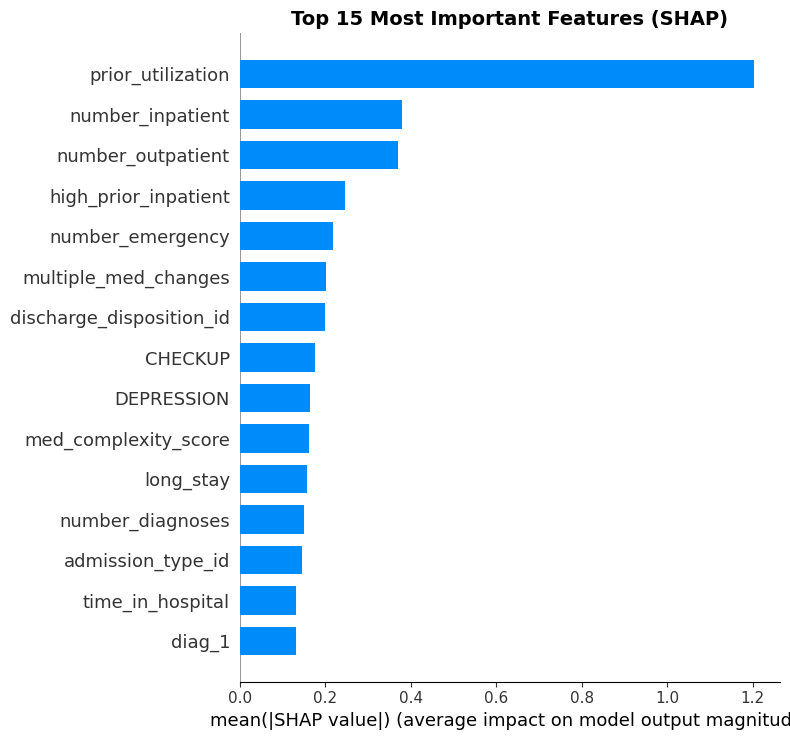

SHAP summary bar plot saved!


In [4]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Most Important Features (SHAP)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_summary_bar.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary bar plot saved!")

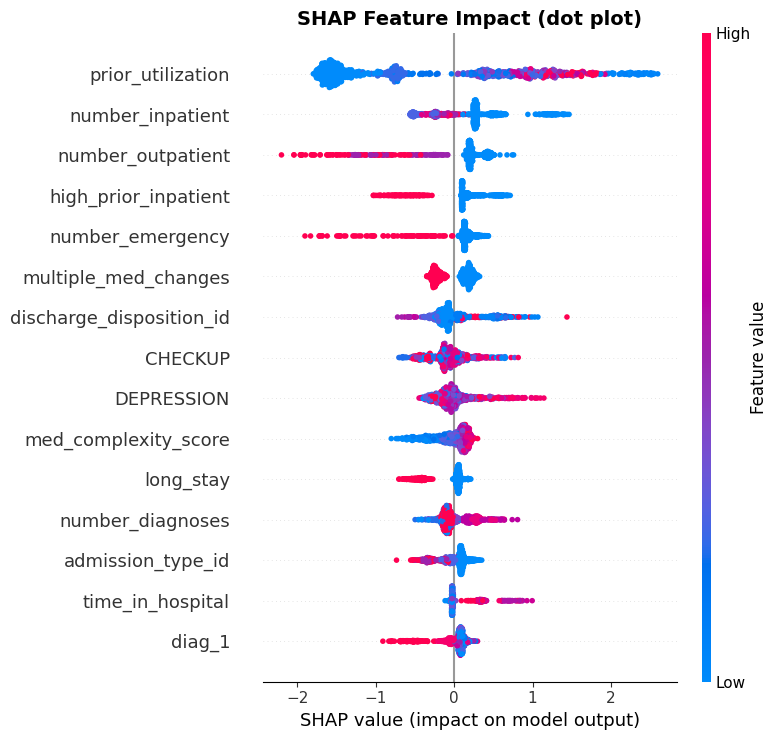

SHAP dot plot saved!


In [5]:
# SHAP Dot Plot (shows direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact (dot plot)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_summary_dot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP dot plot saved!")

High risk patient risk score: 0.9993


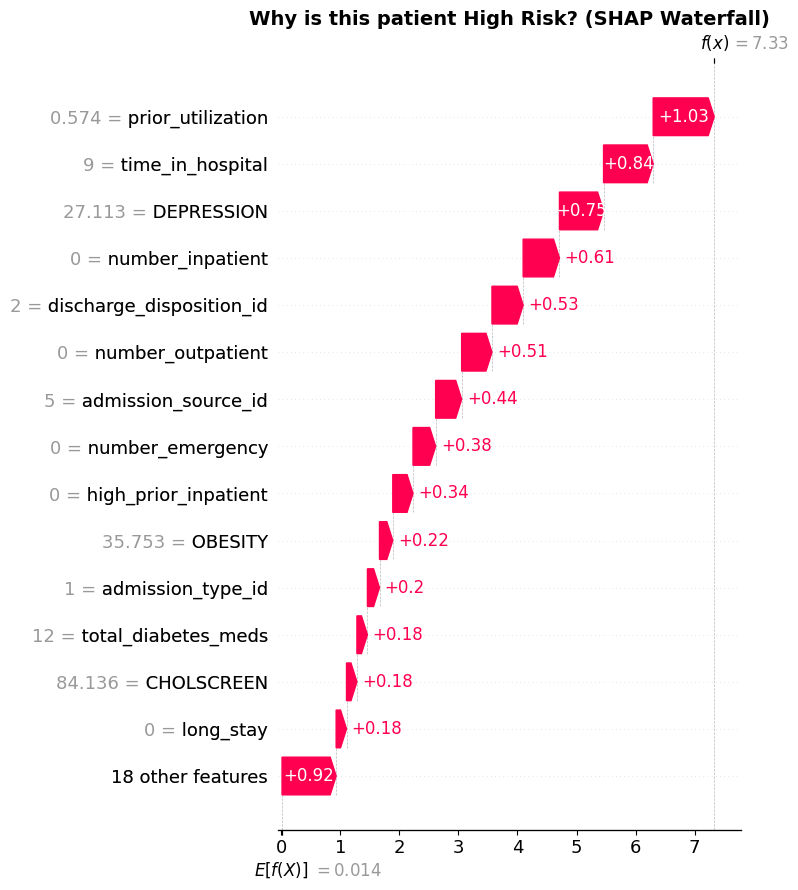

SHAP waterfall plot saved!


In [7]:
# SHAP Waterfall plot for one high risk patient
# Find a high risk patient first
y_prob_sample = best_model.predict_proba(X_sample)[:, 1]
high_risk_idx = y_prob_sample.argmax()

print(f"High risk patient risk score: {y_prob_sample[high_risk_idx]:.4f}")

# Create waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[high_risk_idx],
        feature_names=all_features
    ),
    max_display=15,
    show=False
)
plt.title("Why is this patient High Risk? (SHAP Waterfall)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../explainability/shap_waterfall.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP waterfall plot saved!")

In [8]:
# Export SHAP feature importance as CSV for Power BI
shap_importance = pd.DataFrame({
    'feature': all_features,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

shap_importance.to_csv("../dashboard/shap_importance.csv", index=False)

print("SHAP importance saved!")
print(f"Top 15 most important features:")
print(shap_importance.head(15).to_string(index=False))

SHAP importance saved!
Top 15 most important features:
                 feature  importance
       prior_utilization    1.203987
        number_inpatient    0.378969
       number_outpatient    0.369845
    high_prior_inpatient    0.245652
        number_emergency    0.217188
    multiple_med_changes    0.201890
discharge_disposition_id    0.200460
                 CHECKUP    0.175481
              DEPRESSION    0.163375
    med_complexity_score    0.163001
               long_stay    0.158330
        number_diagnoses    0.151565
       admission_type_id    0.145160
        time_in_hospital    0.131662
                  diag_1    0.130591


In [9]:
## Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
print("Running GridSearchCV... (this may take 5-10 minutes)")

# Define parameter grid
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb_tune = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

grid_search = GridSearchCV(
    xgb_tune,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Use smaller sample for speed
X_tune = X_train.sample(20000, random_state=42)
y_tune = y_train[X_tune.index]

grid_search.fit(X_tune, y_tune)

print(f"GridSearchCV done!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

Running GridSearchCV... (this may take 5-10 minutes)


NameError: name 'XGBClassifier' is not defined